# Loan Form Computer Vision Pipeline
This notebook demonstrates the final integration interface of the Computer Vision module.
The module performs:
1. Form image alignment
2. Numeric digit recognition
3. Checkbox extraction
4. Validation and review detection
5. Conversion to an ML ready feature row

In [32]:
from google.colab import files
from pathlib import Path
import zipfile
import io
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt

In [33]:
import numpy as np

In [34]:
uploaded = files.upload()
zip_name = next(
    name for name in uploaded
    if name.endswith(".zip")
)

Saving Loan_CV_Project.zip to Loan_CV_Project.zip


In [35]:
with zipfile.ZipFile(
    io.BytesIO(uploaded[zip_name])
) as archive:
    archive.extractall("/content")

In [36]:
PROJECT_PATH = Path("/content/Loan_CV_Project")
os.chdir(PROJECT_PATH)
print("Project directory:", Path.cwd())

Project directory: /content/Loan_CV_Project


In [37]:
from loan_cv import FormExtractor, build_feature_row
from loan_cv.digits import CNNRecognizer
from loan_cv.imaging import PhotoError

## 2. Model Configuration

In [38]:
REFERENCE_PATH = Path(
    "assets/Loan_Form_Reference.png"
)
CNN_CHECKPOINT = Path(
    "models/digit_cnn.pt"
)
DIGIT_CONFIDENCE = 0.90
RATIO_DECIMALS = 4

###LoanFormCV Object

In [39]:
class LoanFormCV:
    """
    Public interface for the Loan Form Computer Vision module.
    Responsibilities:
    1. Load the digit recognition model.
    2. Align and extract fields from a photographed loan form.
    3. Report fields requiring manual review.
    4. Convert confirmed extraction results into an ML-ready row.
    """
    def __init__(
        self,
        reference_path,
        checkpoint_path,
        digit_confidence=0.90,
        ratio_decimals=4
    ):
        self.reference_path = Path(reference_path)
        self.checkpoint_path = Path(checkpoint_path)
        self.ratio_decimals = ratio_decimals
        self.recognizer = CNNRecognizer(
            self.checkpoint_path
        )
        self.extractor = FormExtractor(
            self.reference_path,
            recognizer=self.recognizer,
            digit_confidence=digit_confidence
        )
    def process_image(self, image_path):
        """
        Process a photographed completed form.
        Returns
        -------
        dict
            Extraction result containing:
            - extracted fields
            - validation results
            - review requirements
            - image quality diagnostics
        """
        result, aligned_image = self.extractor.extract(
            image_path
        )
        return {
            "result": result,
            "aligned_image": aligned_image
        }
    def build_features(
        self,
        result,
        corrections=None,
        confirmed=False
    ):
        """
        Convert a confirmed extraction result into
        a one-row DataFrame ready for the ML pipeline.
        """
        return build_feature_row(
            result=result,
            corrections=corrections,
            confirmed=confirmed,
            ratio_decimals=self.ratio_decimals
        )
    def get_template_path(self):
        """
        Return the printable reference form path.
        """
        return self.reference_path

## 3. Initialize the CV Service
The front partner should initialize this service once when the application starts.

In [40]:
service = LoanFormCV(
    reference_path=REFERENCE_PATH,
    checkpoint_path=CNN_CHECKPOINT,
    digit_confidence=DIGIT_CONFIDENCE,
    ratio_decimals=RATIO_DECIMALS
)
print("Loan Form CV service initialized successfully.")

Loan Form CV service initialized successfully.


## 4. Printable Form Template
This is the fixed-layout form expected by the CV pipeline.
The user should:
1. Print this form.
2. Fill the fields manually.
3. Photograph the complete sheet.
4. Upload the photograph to the application.

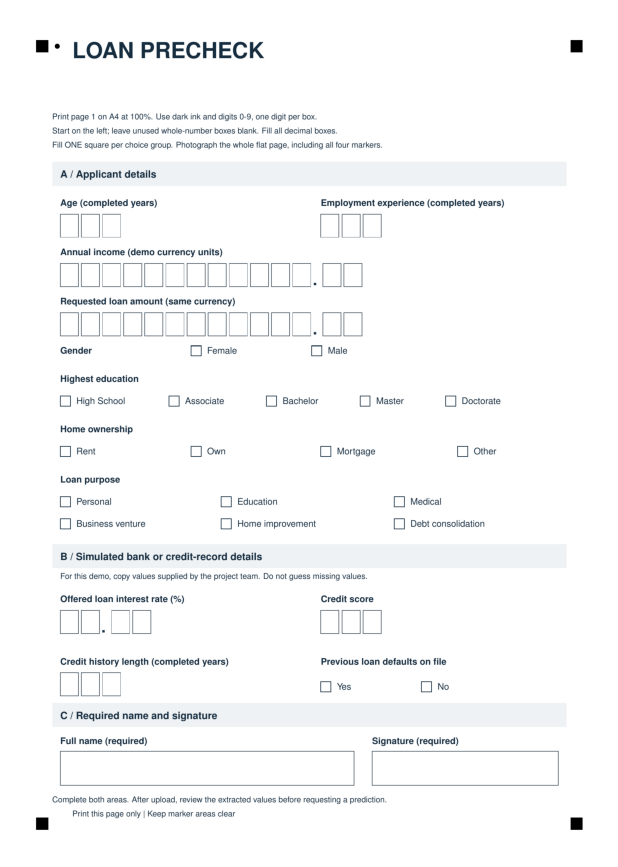

In [41]:
template_path = service.get_template_path()
template_image = cv2.imread(
    str(template_path)
)
plt.figure(figsize=(8, 11))
plt.imshow(
    cv2.cvtColor(
        template_image,
        cv2.COLOR_BGR2RGB
    )
)
plt.axis("off")
plt.show()

## 5. Process a Completed Form
The front partner sends the uploaded photograph to:
`service.process_image(image_path)`

In [42]:
TEST_IMAGE_PATH = Path(
    "assets/photo_03.jpeg"
)
try:
    processed = service.process_image(
        TEST_IMAGE_PATH
    )
    result = processed["result"]
    aligned_image = processed["aligned_image"]
    print("Image processed successfully.")
except PhotoError as error:
    result = None
    aligned_image = None
    print("Photo rejected:")
    print(error)

Image processed successfully.


###Showing the attached image

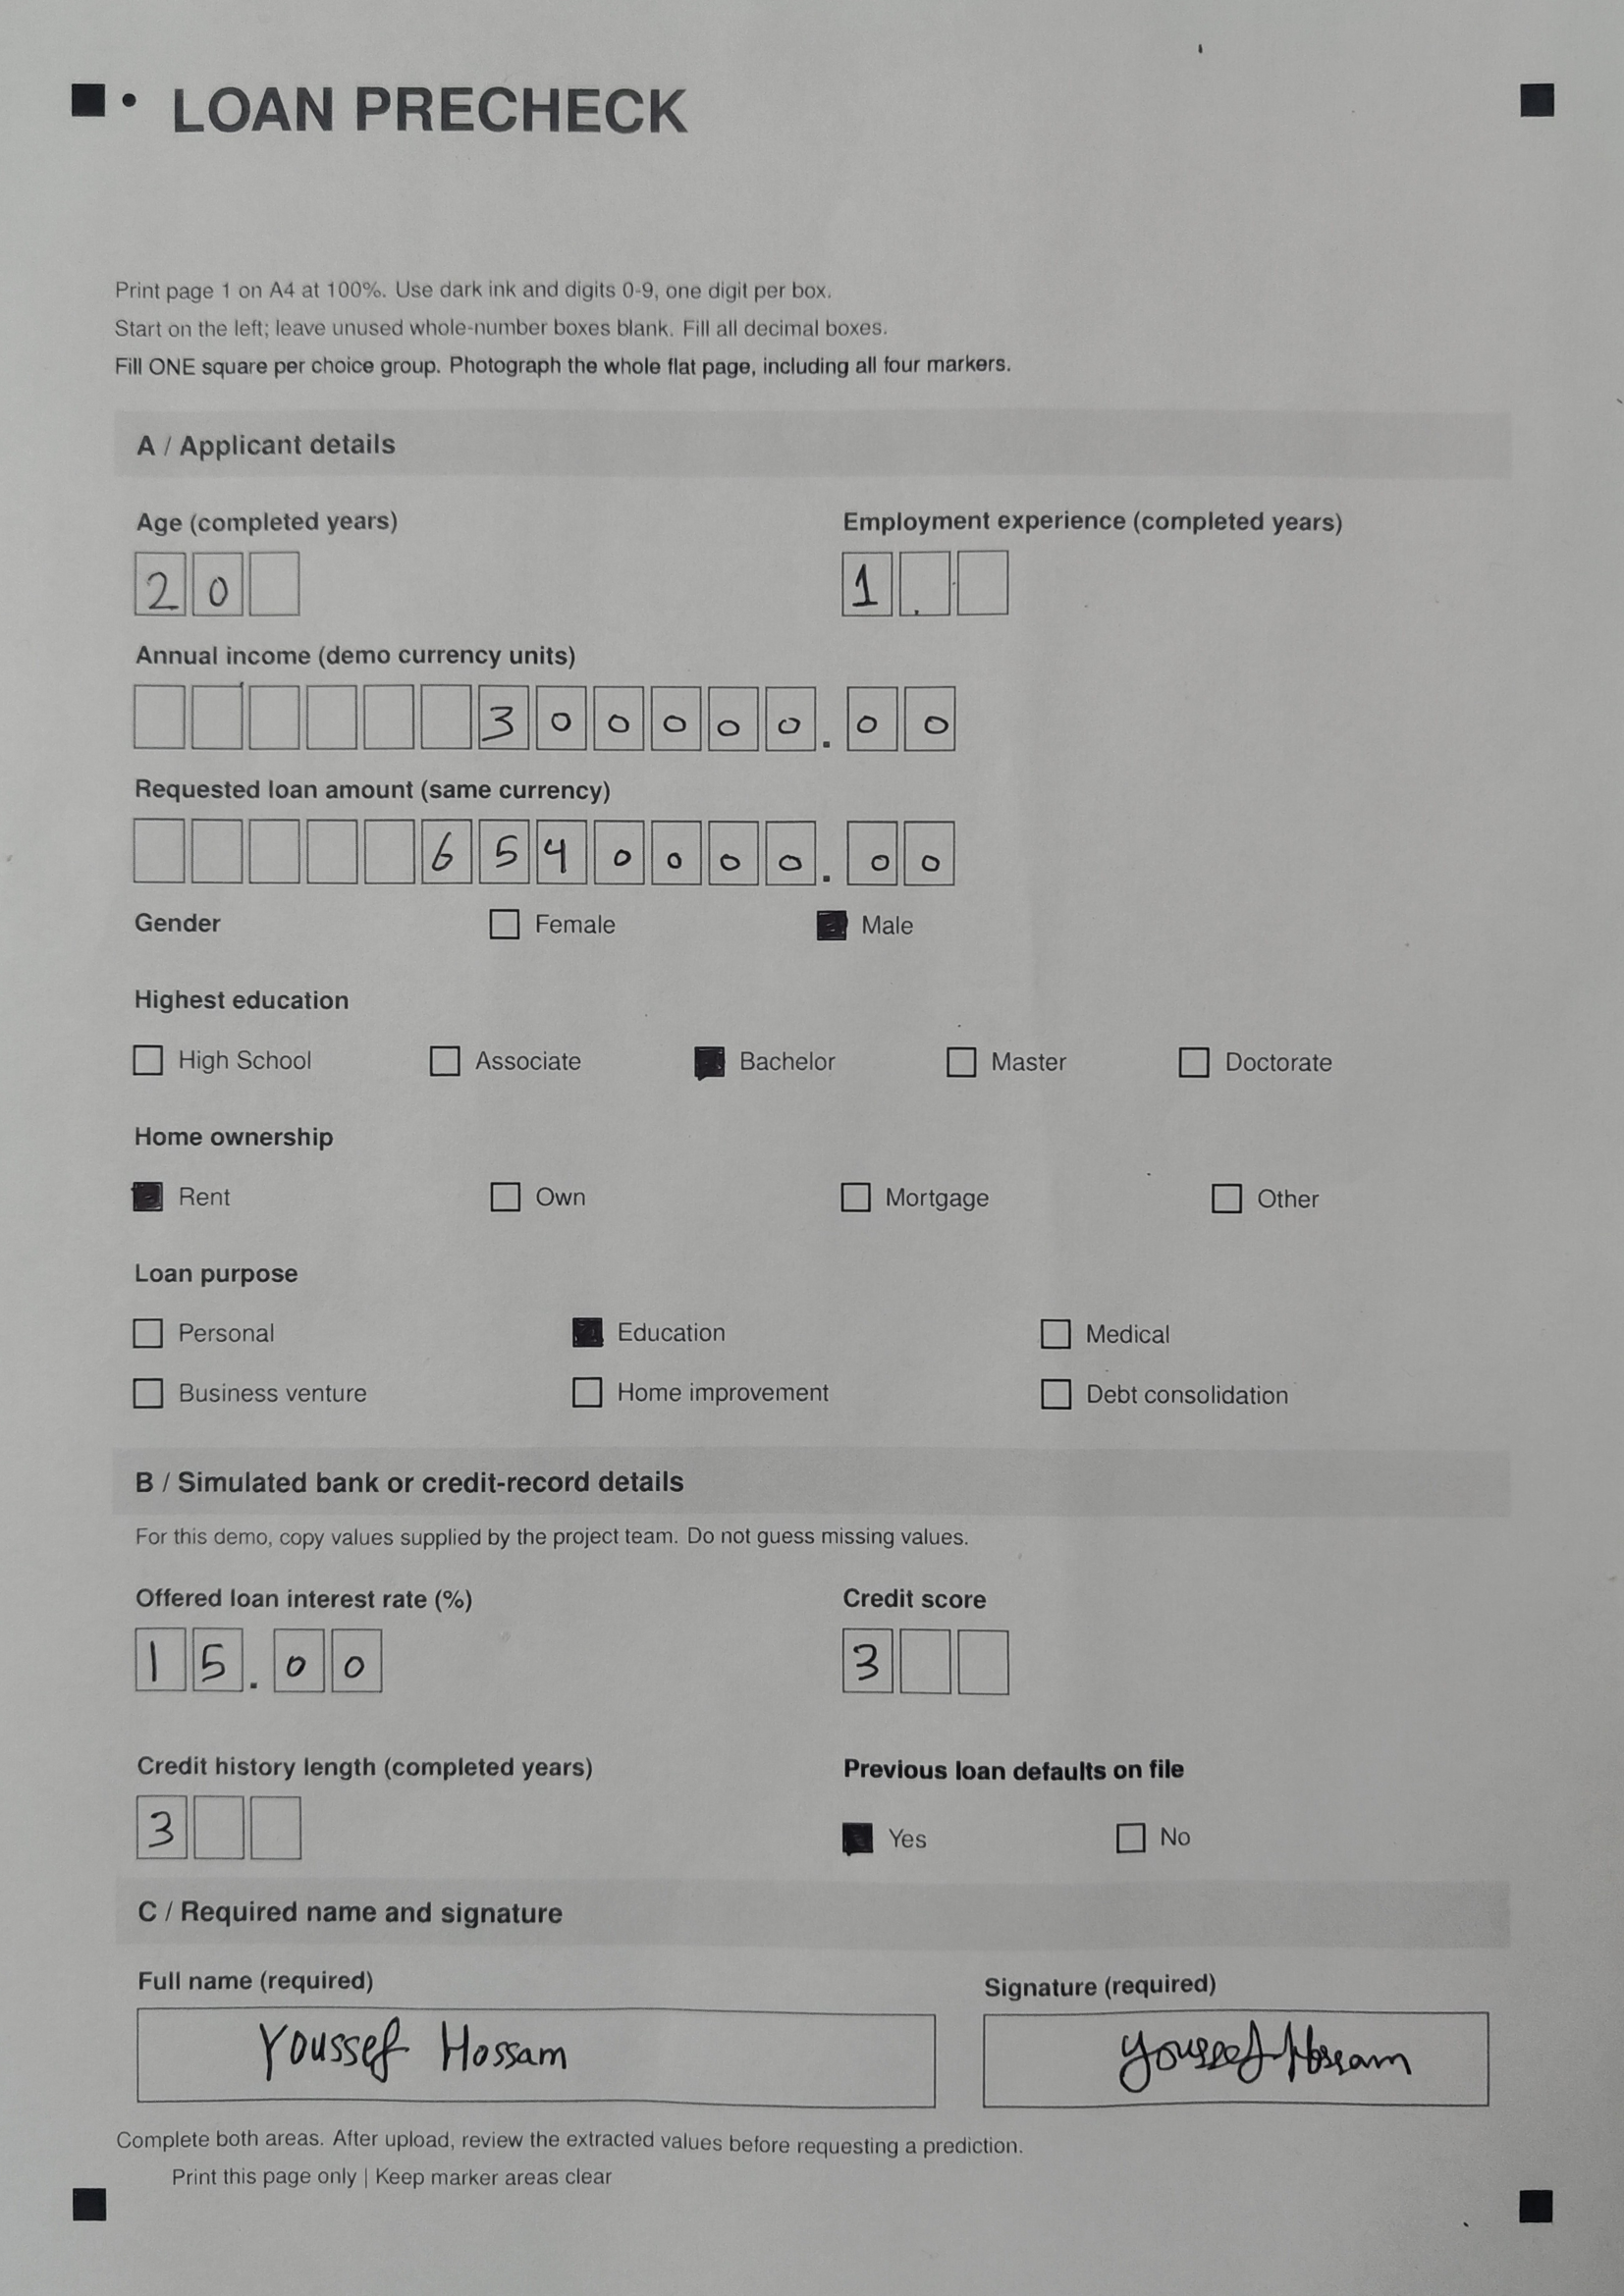

In [43]:
from PIL import Image
from IPython.display import display

if aligned_image is not None:
    gray = cv2.cvtColor(aligned_image, cv2.COLOR_BGR2GRAY)
    mask = gray < 245
    ys, xs = np.where(mask)
    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()
    cropped_image = aligned_image[y1:y2+1, x1:x2+1]
    rgb_image = cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB)
    display(Image.fromarray(rgb_image))

In [44]:
if result is not None:
    extracted_fields = pd.DataFrame([
        {
            "field": field_name,
            "value": field_info["value"],
            "status": field_info["status"],
            "issues": ", ".join(
                field_info["issues"]
            )
        }
        for field_name, field_info
        in result["fields"].items()
    ])
    display(extracted_fields)

,field,value,status,issues
0,person_age,20,ok,
1,person_emp_exp,1,ok,
2,person_income,300000.0,ok,
3,loan_amnt,6540000.0,ok,
4,loan_int_rate,15.0,ok,
5,credit_score,3,ok,
6,cb_person_cred_hist_length,3,ok,
7,person_gender,male,ok,
8,person_education,Bachelor,ok,
9,person_home_ownership,RENT,ok,


In [45]:
if result is not None:
    print(
        "Extraction complete:",
        result["extraction_complete"]
    )
    print(
        "Fields requiring review:",
        result["review_required"]
    )

Extraction complete: True
Fields requiring review: []


## 6. Manual Review / Corrections
If a field is marked as `review`, the frontend should allow
the user to confirm or correct that value.
Only corrected fields need to be provided.

In [46]:
corrections = {}

In [47]:
# Example:
# corrections = {
#     "person_age": 20,
#     "credit_score": 3
# }

In [48]:
if result is not None:
    try:
        feature_row = service.build_features(
            result,
            corrections=corrections,
            confirmed=True
        )
        print(
            "ML-ready feature row:"
        )
        display(feature_row)
    except ValueError as error:
        feature_row = None
        print(
            "Cannot build feature row:"
        )
        print(error)

ML-ready feature row:


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
0,20,male,Bachelor,300000.0,1,RENT,6540000.0,EDUCATION,15.0,21.8,3,3,Yes


## 7. Machine Learning Integration
The Computer Vision module ends here.
`feature_row` is the final output that should be passed
to the trained Machine Learning preprocessing/model pipeline.
Example:
```python
prediction = ml_pipeline.predict(feature_row)